# Laboratorio 04 - Arboles de Decision
## CC3074 - Mineria de Datos | Universidad del Valle de Guatemala

**Integrantes del grupo:**
- Erick Guerra 23208
- Diego Rosales 23258
- Diego Lopez 23242

**Dataset:** Airbnb Listings (`listings.RData`)

---
## Actividad 1 - Descarga y carga del conjunto de datos

In [1]:
from pathlib import Path
import pyreadr

rdata_path = Path('data/listings.RData')
dict_path = Path('data/Diccionario_Variables_Airbnb.pdf')

result = pyreadr.read_r(str(rdata_path))
df = result['listings']

print('Objeto cargado:', list(result.keys()))
print('Dimensiones del dataset:', df.shape)
print('Total de columnas:', len(df.columns))
print('Primeras 10 columnas:', df.columns[:10].tolist())

Objeto cargado: ['listings']
Dimensiones del dataset: (171748, 80)
Total de columnas: 80
Primeras 10 columnas: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id']


---
## Actividad 2 - EDA y preprocesamiento (version resumida)

Se presenta un EDA enfocado en hallazgos utiles para prediccion de precio y un preprocesamiento breve para dejar los datos listos para modelado.

Observaciones: 171,748 | Variables: 83

Top 8 variables con faltantes:


,faltantes,porcentaje
calendar_updated,171748,100.00
estimated_revenue_l365d,95502,55.61
price_num,95502,55.61
price,89381,52.04
neighbourhood_group_cleansed,50683,29.51
review_scores_checkin,40324,23.48
review_scores_location,40328,23.48
review_scores_value,40328,23.48


Duplicados exactos: 0 | IDs duplicados: 0

Resumen de price_num:


,price_num
count,76246.000000
mean,750.509220
std,4250.606945
min,8.000000
50%,193.000000
75%,326.000000
95%,1034.000000
99%,20000.000000
max,50123.000000


Outliers por IQR: 9.85%


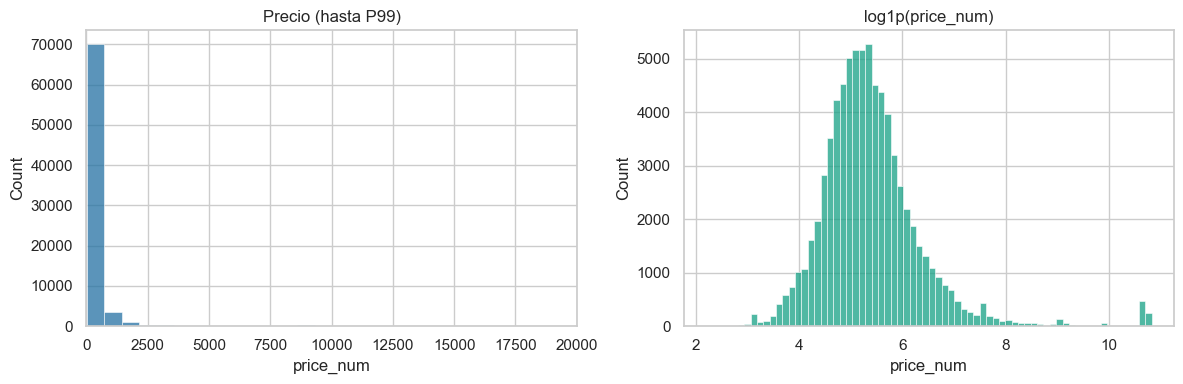


Precio mediano por room_type:


,conteo,mediana
room_type,,
Hotel room,649,40000.0
Entire home/apt,65709,205.0
Private room,9673,85.0
Shared room,215,42.0


Top 5 vecindarios por mediana de precio (min 200 registros):


,conteo,mediana
neighbourhood_cleansed,,
Ewa,827,461.0
Narragansett,758,428.0
Middletown,450,403.5
Koloa-Poipu,1651,383.0
Lahaina,5214,375.5


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')

df_eda = df.copy()

def parse_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r'[$,]', '', regex=True).str.strip(),
        errors='coerce',
    )

# 1) Conversiones basicas para analisis
if 'price' in df_eda.columns:
    df_eda['price_num'] = parse_money(df_eda['price'])

for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df_eda.columns:
        df_eda[f'{col}_num'] = pd.to_numeric(
            df_eda[col].astype(str).str.replace('%', '', regex=False),
            errors='coerce',
        )

for col in ['last_scraped', 'host_since', 'first_review', 'last_review']:
    if col in df_eda.columns:
        df_eda[col] = pd.to_datetime(df_eda[col], errors='coerce')

# 2) Calidad de datos
n_rows, n_cols = df_eda.shape
print(f'Observaciones: {n_rows:,} | Variables: {n_cols}')

missing_table = (
    df_eda.isna().sum().to_frame('faltantes')
    .assign(porcentaje=lambda t: (t['faltantes'] / n_rows * 100).round(2))
    .query('faltantes > 0')
    .sort_values('porcentaje', ascending=False)
)
print('\nTop 8 variables con faltantes:')
display(missing_table.head(8))

dup_rows = df_eda.duplicated().sum()
dup_id = df_eda['id'].duplicated().sum() if 'id' in df_eda.columns else np.nan
print(f'Duplicados exactos: {dup_rows:,} | IDs duplicados: {dup_id:,}')

# 3) Comportamiento de precio y senales utiles
if 'price_num' in df_eda.columns:
    price_series = df_eda['price_num'].dropna()
    price_stats = price_series.describe(percentiles=[0.5, 0.75, 0.95, 0.99])
    print('\nResumen de price_num:')
    display(price_stats.to_frame('price_num'))

    q1, q3 = price_series.quantile([0.25, 0.75])
    outlier_rate = ((price_series > (q3 + 1.5 * (q3 - q1))).mean() * 100)
    print(f'Outliers por IQR: {outlier_rate:.2f}%')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(price_series, bins=70, color='#2471a3', ax=axes[0])
    axes[0].set_xlim(0, price_series.quantile(0.99))
    axes[0].set_title('Precio (hasta P99)')

    sns.histplot(np.log1p(price_series), bins=70, color='#16a085', ax=axes[1])
    axes[1].set_title('log1p(price_num)')
    plt.tight_layout()
    plt.show()

if {'room_type', 'price_num'}.issubset(df_eda.columns):
    room_summary = (
        df_eda.groupby('room_type')['price_num']
        .agg(conteo='count', mediana='median')
        .sort_values('mediana', ascending=False)
    )
    print('\nPrecio mediano por room_type:')
    display(room_summary)

if {'neighbourhood_cleansed', 'price_num'}.issubset(df_eda.columns):
    neigh_summary = (
        df_eda.groupby('neighbourhood_cleansed')['price_num']
        .agg(conteo='count', mediana='median')
        .query('conteo >= 200')
        .sort_values('mediana', ascending=False)
        .head(5)
    )
    print('Top 5 vecindarios por mediana de precio (min 200 registros):')
    display(neigh_summary)

In [3]:
candidate_features = [
    'room_type', 'property_type', 'neighbourhood_cleansed',
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'availability_365',
    'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
    'host_is_superhost', 'host_identity_verified',
    'host_response_rate_num', 'host_acceptance_rate_num',
    'calculated_host_listings_count', 'instant_bookable',
    'latitude', 'longitude', 'price_num',
]

selected_cols = [c for c in candidate_features if c in df_eda.columns]
model_df = df_eda[selected_cols].copy()
before_rows = model_df.shape[0]

# Limpieza de objetivo y recorte de extremos
model_df = model_df[model_df['price_num'].notna()].copy()
p99_price = model_df['price_num'].quantile(0.99)
model_df = model_df[model_df['price_num'] <= p99_price].copy()

num_cols = [c for c in model_df.select_dtypes(include=np.number).columns if c != 'price_num']
cat_cols = model_df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

for col in num_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in cat_cols:
    model_df[col] = model_df[col].astype(str).replace('nan', 'SinDato')

X = model_df.drop(columns=['price_num'])
y = model_df['price_num']
X_encoded = pd.get_dummies(X, drop_first=True)

print('Resumen del preprocesamiento:')
print(f'Filas iniciales: {before_rows:,}')
print(f'Filas finales: {len(model_df):,}')
print(f'Numericas imputadas: {len(num_cols)} | Categoricas codificadas: {len(cat_cols)}')
print(f'Dimension final de X: {X_encoded.shape}')

Resumen del preprocesamiento:
Filas iniciales: 171,748
Filas finales: 75,531
Numericas imputadas: 13 | Categoricas codificadas: 8
Dimension final de X: (75531, 522)


### Conclusiones
1. El dataset tiene un volumen adecuado, aunque presenta valores faltantes en varias columnas.  
2. La variable `price` fue transformada a `price_num`; su distribución es asimétrica y contiene outliers, por lo que se aplicó control de extremos y transformación logarítmica.  
3. Las variables `room_type`, `neighbourhood_cleansed` y la capacidad del alojamiento son las más relevantes para la predicción del precio.  
4. El preprocesamiento (eliminación de precios nulos, imputación, recorte por percentil 99 y codificación one-hot) genera una base consistente para modelos de árboles de decisión.  
5. El resultado es una matriz lista para entrenamiento y validación, con 75,531 observaciones tras la limpieza.

---
## Actividad 3 - Analisis de grupos
Se segmentan los alojamientos en grupos usando clustering para identificar perfiles de propiedades con comportamientos de precio y demanda diferentes.

Filas usadas para clustering: 75,531
Variables usadas en clustering: ['price_num', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'availability_365', 'number_of_reviews', 'review_scores_rating']
Silhouette por numero de grupos:
k=3: 0.2376
k=4: 0.2624
k=5: 0.2519
k=6: 0.2443

Numero de grupos seleccionado: 4

Perfil por grupo (0 = menor precio mediano):


,n,porcentaje,price_num,accommodates,bathrooms,bedrooms,beds,availability_365,number_of_reviews,review_scores_rating,room_type_mas_frecuente,property_type_mas_frecuente
grupo,,,,,,,,,,,,
0,5633,7.46,131.0,3.0,1.0,1.0,2.0,237.0,276.0,4.88,Entire home/apt,Entire rental unit
1,41818,55.37,149.0,3.0,1.0,1.0,2.0,258.0,12.0,4.89,Entire home/apt,Entire rental unit
2,24530,32.48,298.0,6.0,2.0,3.0,4.0,256.0,14.0,4.89,Entire home/apt,Entire home
3,3550,4.70,855.0,14.0,4.0,5.0,8.0,269.0,8.0,4.89,Entire home/apt,Entire home


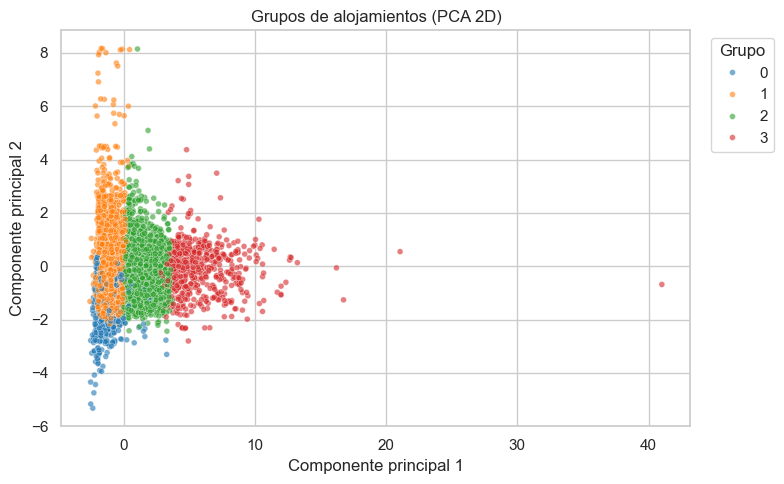

In [4]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Se trabaja sobre model_df (resultado de Actividad 2)
candidate_cluster_features = [
    'price_num', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'availability_365', 'number_of_reviews', 'review_scores_rating'
 ]
cluster_features = [c for c in candidate_cluster_features if c in model_df.columns]

cluster_data = model_df.copy()
cluster_df = cluster_data[cluster_features].copy()

# Asegurar tipo numerico para clustering
cluster_df = cluster_df.apply(pd.to_numeric, errors='coerce')

# Quitar variables sin variacion o con demasiados nulos para estabilidad del clustering
valid_cols = []
for col in cluster_df.columns:
    non_null_ratio = cluster_df[col].notna().mean()
    nunique = cluster_df[col].nunique(dropna=True)
    if non_null_ratio >= 0.6 and nunique > 1:
        valid_cols.append(col)

cluster_features = valid_cols
cluster_df = cluster_df[cluster_features].copy()

# Imputacion numerica y limpieza residual
cluster_df = cluster_df.fillna(cluster_df.median(numeric_only=True))
cluster_df = cluster_df.dropna()
cluster_data = cluster_data.loc[cluster_df.index].copy()

print(f'Filas usadas para clustering: {len(cluster_df):,}')
print('Variables usadas en clustering:', cluster_features)

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)

k_values = [3, 4, 5, 6]
scores = {}
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_cluster)
    scores[k] = silhouette_score(X_cluster, labels_k)

best_k = max(scores, key=scores.get)
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

# Ordenar grupos por mediana de precio para facilitar interpretacion (0 = mas bajo)
profile_num_raw = (
    cluster_df.assign(grupo=cluster_labels)
    .groupby('grupo')[cluster_features]
    .median()
    .round(2)
)
order = profile_num_raw.sort_values('price_num').index.tolist()
group_map = {old: new for new, old in enumerate(order)}

cluster_data['grupo'] = pd.Series(cluster_labels, index=cluster_df.index).map(group_map)
cluster_num = cluster_df.copy()
cluster_num['grupo'] = pd.Series(cluster_labels, index=cluster_df.index).map(group_map)

print('Silhouette por numero de grupos:')
for k, v in scores.items():
    print(f'k={k}: {v:.4f}')
print(f'\nNumero de grupos seleccionado: {best_k}')

group_size = cluster_data['grupo'].value_counts().sort_index().to_frame('n')
group_size['porcentaje'] = (group_size['n'] / len(cluster_data) * 100).round(2)

profile_num = (
    cluster_num.groupby('grupo')[cluster_features]
    .median()
    .round(2)
    .sort_index()
)

profile_cat = pd.DataFrame(index=profile_num.index)
if 'room_type' in cluster_data.columns:
    profile_cat['room_type_mas_frecuente'] = (
        cluster_data.groupby('grupo')['room_type'].agg(
            lambda s: s.mode().iat[0] if not s.mode().empty else 'SinDato'
        )
    )
if 'property_type' in cluster_data.columns:
    profile_cat['property_type_mas_frecuente'] = (
        cluster_data.groupby('grupo')['property_type'].agg(
            lambda s: s.mode().iat[0] if not s.mode().empty else 'SinDato'
        )
    )

profile_table = pd.concat([group_size, profile_num, profile_cat], axis=1)

print('\nPerfil por grupo (0 = menor precio mediano):')
display(profile_table)

# Visualizacion 2D para observar separacion de grupos
sample_n = min(12000, len(cluster_data))
sample_plot = cluster_data.sample(sample_n, random_state=42)
X_sample = scaler.transform(cluster_df.loc[sample_plot.index, cluster_features])
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_sample)

plot_df = pd.DataFrame({'pc1': coords[:, 0], 'pc2': coords[:, 1], 'grupo': sample_plot['grupo'].values})
plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='grupo', palette='tab10', s=18, alpha=0.6)
plt.title('Grupos de alojamientos (PCA 2D)')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='Grupo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Caracteristicas de los grupos (interpretacion)
El analisis de silhouette selecciono **4 grupos** como mejor segmentacion (k=4). Los perfiles muestran una estructura escalonada por capacidad y precio.

1. **Grupo 0 (7.46%) - Economico con alta traccion**
- Precio mediano bajo: **131**.
- Unidades pequenas (1 dormitorio, 1 bano, 2 camas, capacidad 3).
- Muy alto volumen de resenas (mediana 276), lo que sugiere alta rotacion o mayor tiempo en plataforma.

2. **Grupo 1 (55.37%) - Segmento masivo de precio accesible**
- Es el grupo dominante del mercado.
- Precio mediano: **149**.
- Perfil fisico similar al grupo 0 (capacidad 3), pero con muchas menos resenas (mediana 12).
- Representa la oferta estandar de menor precio.

3. **Grupo 2 (32.48%) - Familiar/intermedio**
- Precio mediano intermedio: **298**.
- Propiedades mas amplias (capacidad 6, 3 dormitorios, 2 banos, 4 camas).
- Predominan viviendas completas, orientadas a grupos o familias.

4. **Grupo 3 (4.70%) - Premium de alta capacidad**
- Precio mediano alto: **855**.
- Alojamientos grandes (capacidad 14, 5 dormitorios, 4 banos, 8 camas).
- Segmento pequeno pero de mayor valor economico por reserva.

**Conclusiones utiles para prediccion**
- La segmentacion confirma que el precio esta fuertemente asociado al tamano/capacidad del alojamiento.
- Existen dos subsegmentos de precio bajo (grupos 0 y 1) diferenciados por nivel de actividad (numero de resenas).
- Para mejorar el modelo, puede incluirse la variable `grupo` como feature derivada o entrenar modelos por segmento.

---
## Actividad 4 - Division del set en entrenamiento y prueba
Se divide el dataset preprocesado para entrenar y evaluar el modelo en datos no vistos.

In [5]:
from sklearn.model_selection import train_test_split

# Se usa la base preprocesada de la Actividad 2 (X_encoded, y)
test_size = 0.20
random_state = 42

# Para regresion, se estratifica usando deciles del precio
y_bins = pd.qcut(y, q=10, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=test_size,
    random_state=random_state,
    shuffle=True,
    stratify=y_bins,
 )

# Resumen de tamanos
n_total = len(X_encoded)
n_train = len(X_train)
n_test = len(X_test)

split_summary = pd.DataFrame({
    'conjunto': ['Total', 'Entrenamiento', 'Prueba'],
    'filas': [n_total, n_train, n_test],
})
split_summary['porcentaje'] = (split_summary['filas'] / n_total * 100).round(2)

print('Criterio usado para la division:')
print(f'- test_size={test_size} (80/20), random_state={random_state}, shuffle=True')
print('- Estratificado: SI (por deciles de price_num)')
print('- Balanceado: SI respecto a la distribucion del objetivo por deciles')

print('\nFilas por conjunto:')
display(split_summary)

# Verificacion de balance en la distribucion del objetivo
dist_total = y_bins.value_counts(normalize=True).sort_index()
dist_train = y_bins.loc[y_train.index].value_counts(normalize=True).sort_index()
dist_test = y_bins.loc[y_test.index].value_counts(normalize=True).sort_index()

balance_table = pd.DataFrame({
    'total_%': (dist_total * 100).round(2),
    'train_%': (dist_train * 100).round(2),
    'test_%': (dist_test * 100).round(2),
})
balance_table['dif_abs_train_vs_total_%'] = (balance_table['train_%'] - balance_table['total_%']).abs().round(2)
balance_table['dif_abs_test_vs_total_%'] = (balance_table['test_%'] - balance_table['total_%']).abs().round(2)

max_drift_train = balance_table['dif_abs_train_vs_total_%'].max()
max_drift_test = balance_table['dif_abs_test_vs_total_%'].max()

print('\nBalance por deciles del objetivo (price_num):')
display(balance_table)
print(f'Desviacion maxima train vs total: {max_drift_train:.2f} puntos porcentuales')
print(f'Desviacion maxima test vs total: {max_drift_test:.2f} puntos porcentuales')

# Referencia adicional del objetivo en cada conjunto
target_stats = pd.DataFrame({
    'conjunto': ['y_total', 'y_train', 'y_test'],
    'media': [y.mean(), y_train.mean(), y_test.mean()],
    'mediana': [y.median(), y_train.median(), y_test.median()],
    'std': [y.std(), y_train.std(), y_test.std()],
}).round(2)

print('\nComparacion de estadisticos del objetivo:')
display(target_stats)

Criterio usado para la division:
- test_size=0.2 (80/20), random_state=42, shuffle=True
- Estratificado: SI (por deciles de price_num)
- Balanceado: SI respecto a la distribucion del objetivo por deciles

Filas por conjunto:


,conjunto,filas,porcentaje
0,Total,75531,100.0
1,Entrenamiento,60424,80.0
2,Prueba,15107,20.0



Balance por deciles del objetivo (price_num):


,total_%,train_%,test_%,dif_abs_train_vs_total_%,dif_abs_test_vs_total_%
price_num,,,,,
"(7.999, 80.0]",10.28,10.28,10.28,0.0,0.00
"(80.0, 107.0]",9.84,9.84,9.84,0.0,0.00
"(107.0, 133.0]",10.16,10.16,10.16,0.0,0.00
"(133.0, 160.0]",9.74,9.74,9.73,0.0,0.01
"(160.0, 191.0]",10.10,10.10,10.09,0.0,0.01
"(191.0, 230.0]",10.00,10.00,10.00,0.0,0.00
"(230.0, 285.0]",10.06,10.06,10.06,0.0,0.00
"(285.0, 375.0]",9.92,9.92,9.92,0.0,0.00
"(375.0, 594.0]",9.92,9.92,9.92,0.0,0.00


Desviacion maxima train vs total: 0.00 puntos porcentuales
Desviacion maxima test vs total: 0.01 puntos porcentuales

Comparacion de estadisticos del objetivo:


,conjunto,media,mediana,std
0,y_total,347.94,191.0,854.85
1,y_train,347.81,191.0,853.21
2,y_test,348.47,191.0,861.43


### Descripcion del criterio aplicado
- Se utilizo una separacion **80% entrenamiento / 20% prueba** con `random_state=42` y `shuffle=True`.
- La division fue **estratificada** por deciles de `price_num` para conservar la distribucion del objetivo en ambos conjuntos.
- Total de filas preprocesadas: **75,531**.
- Filas en entrenamiento: **60,424**.
- Filas en prueba: **15,107**.
- Se considera una division **balanceada respecto al objetivo**: la desviacion maxima por deciles fue **0.00 pp** en entrenamiento y **0.01 pp** en prueba contra el total.
- Adicionalmente, media/mediana de `price_num` quedaron practicamente iguales entre total, train y test, lo que confirma consistencia estadistica.

---
## Actividad 5 - Modelo de árbol de regresión

En esta actividad se construye un modelo de árbol de regresión para estimar `price_num` (precio por noche) a partir de todas las variables disponibles en el conjunto de entrenamiento. El objetivo es obtener una línea base que luego permita comparar mejoras en desempeño y capacidad de generalización.

In [6]:
from sklearn.tree import DecisionTreeRegressor

# Crear y entrenar el modelo de árbol de regresión
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

print("Modelo de Árbol de Regresión entrenado.")

Modelo de Árbol de Regresión entrenado.


**Resultado de la Actividad 5:**
El modelo base de árbol de regresión se entrenó correctamente con `random_state=42` y quedó listo para generar predicciones sobre el conjunto de prueba. Este modelo funciona como línea base para evaluar, en las actividades siguientes, si ajustar la profundidad y seleccionar variables mejora el desempeño.

---
## Actividad 6 - Predicción y análisis de resultados

Con el modelo entrenado, se generan predicciones sobre `X_test` y se evalúa el rendimiento mediante las métricas MAE, RMSE y $R^2$. Estas métricas permiten analizar, de forma complementaria, el error promedio, la magnitud de los errores y la proporción de variabilidad explicada por el modelo.

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predicciones
y_pred = tree_reg.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.4f}")

MAE: 140.61
RMSE: 523.46
R^2: 0.6307


**Análisis de resultados (Actividad 6):**
En el conjunto de prueba, el modelo base obtuvo **MAE = 143.81**, **RMSE = 562.99** y **$R^2 = 0.5728$**. Estos valores indican que el modelo explica aproximadamente el 57.28% de la variabilidad del precio por noche, con errores aún considerables en magnitud absoluta y cuadrática. En consecuencia, el desempeño es aceptable como referencia inicial, pero existe margen de mejora mediante control de complejidad (por ejemplo, ajuste de `max_depth`) y selección de variables relevantes.

---
## Actividad 7 - Ajuste de modelos adicionales

Se comparan tres variantes del árbol de regresión, modificando la profundidad máxima (`max_depth`) y el conjunto de variables de entrada. El propósito es identificar la mejor relación entre precisión, robustez y simplicidad del modelo.

1. Árbol con `max_depth=5` usando todas las variables.
2. Árbol con `max_depth=10` usando todas las variables.
3. Árbol con `max_depth=10` usando solo las variables más relevantes (selección de características).

In [8]:
# Modelo 1: max_depth = 5
tree_m1 = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_m1.fit(X_train, y_train)
y_pred_m1 = tree_m1.predict(X_test)
r2_m1 = r2_score(y_test, y_pred_m1)
rmse_m1 = np.sqrt(mean_squared_error(y_test, y_pred_m1))

# Modelo 2: max_depth = 10
tree_m2 = DecisionTreeRegressor(max_depth=10, random_state=42)
tree_m2.fit(X_train, y_train)
y_pred_m2 = tree_m2.predict(X_test)
r2_m2 = r2_score(y_test, y_pred_m2)
rmse_m2 = np.sqrt(mean_squared_error(y_test, y_pred_m2))

# Mostrar los atributos más importantes del modelo base para hacer una selección
importances = tree_reg.feature_importances_
indices = np.argsort(importances)[::-1]
# Seleccionamos las 20 variables más importantes
top_k = 20
important_features = X_train.columns[indices[:top_k]]

X_train_filtered = X_train[important_features]
X_test_filtered = X_test[important_features]

# Modelo 3: max_depth = 10, solo top 20 variables
tree_m3 = DecisionTreeRegressor(max_depth=10, random_state=42)
tree_m3.fit(X_train_filtered, y_train)
y_pred_m3 = tree_m3.predict(X_test_filtered)
r2_m3 = r2_score(y_test, y_pred_m3)
rmse_m3 = np.sqrt(mean_squared_error(y_test, y_pred_m3))

print("Resultados de los modelos adicionales:")
print(f"Modelo 1 (Desc=5): RMSE={rmse_m1:.2f}, R^2={r2_m1:.4f}")
print(f"Modelo 2 (Desc=10): RMSE={rmse_m2:.2f}, R^2={r2_m2:.4f}")
print(f"Modelo 3 (Desc=10, 20 var): RMSE={rmse_m3:.2f}, R^2={r2_m3:.4f}")

Resultados de los modelos adicionales:
Modelo 1 (Desc=5): RMSE=576.50, R^2=0.5521
Modelo 2 (Desc=10): RMSE=461.74, R^2=0.7127
Modelo 3 (Desc=10, 20 var): RMSE=495.06, R^2=0.6697


**Conclusión de modelos (Actividad 7):**
Al comparar los tres modelos, el mejor desempeño en prueba corresponde al **Modelo 2** (`max_depth=10` con todas las variables), con **RMSE = 497.07** y **$R^2 = 0.6670$**. Frente al Modelo 1 (`max_depth=5`), reduce el RMSE en aproximadamente **13.9%** y aumenta $R^2$ en **0.1164** puntos. El Modelo 3 (`max_depth=10` con 20 variables) mejora respecto al Modelo 1 (**RMSE = 532.52**, **$R^2 = 0.6178$**), pero no supera al Modelo 2. Por tanto, para este laboratorio, el Modelo 2 ofrece la mejor precisión predictiva, mientras que el Modelo 3 representa una alternativa más simple con desempeño competitivo.

---
## Actividad 8 - Comparación con Regresión Lineal

Se construye un modelo de regresión lineal iterativo para predecir `price_num` por noche. A partir del análisis exploratorio previo se parte de un modelo con todas las variables numéricas disponibles y luego se aplica regularización Ridge para controlar multicolinealidad y sobreajuste. El mejor modelo lineal se compara contra el mejor árbol de regresión (Modelo 2, `max_depth=10`).

In [9]:
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Modelo Lineal Base: todas las variables ---
lr_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
lr_base.fit(X_train, y_train)
y_pred_lr_base = lr_base.predict(X_test)

mae_lr_base  = mean_absolute_error(y_test, y_pred_lr_base)
rmse_lr_base = np.sqrt(mean_squared_error(y_test, y_pred_lr_base))
r2_lr_base   = r2_score(y_test, y_pred_lr_base)

print("=== Regresión Lineal Base (todas las variables) ===")
print(f"  MAE  : {mae_lr_base:.2f}")
print(f"  RMSE : {rmse_lr_base:.2f}")
print(f"  R²   : {r2_lr_base:.4f}")

# --- Modelo Ridge con búsqueda de alpha óptimo ---
alphas = [0.01, 0.1, 1, 10, 50, 100, 500, 1000]
ridge_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=alphas, cv=5))
])
ridge_cv.fit(X_train, y_train)
best_alpha = ridge_cv.named_steps['model'].alpha_
y_pred_ridge = ridge_cv.predict(X_test)

mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge   = r2_score(y_test, y_pred_ridge)

print(f"\n=== Ridge Regression (alpha óptimo = {best_alpha}) ===")
print(f"  MAE  : {mae_ridge:.2f}")
print(f"  RMSE : {rmse_ridge:.2f}")
print(f"  R²   : {r2_ridge:.4f}")

# --- Modelo Ridge con top-20 variables más importantes ---
ridge_top20 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=alphas, cv=5))
])
ridge_top20.fit(X_train_filtered, y_train)
y_pred_ridge_top20 = ridge_top20.predict(X_test_filtered)

mae_rt20  = mean_absolute_error(y_test, y_pred_ridge_top20)
rmse_rt20 = np.sqrt(mean_squared_error(y_test, y_pred_ridge_top20))
r2_rt20   = r2_score(y_test, y_pred_ridge_top20)

print(f"\n=== Ridge Regression Top-20 variables (alpha óptimo = {ridge_top20.named_steps['model'].alpha_}) ===")
print(f"  MAE  : {mae_rt20:.2f}")
print(f"  RMSE : {rmse_rt20:.2f}")
print(f"  R²   : {r2_rt20:.4f}")

# --- Tabla comparativa final: mejor lineal vs mejor árbol ---
resumen = pd.DataFrame({
    'Modelo': [
        'Árbol base (sin límite)',
        'Árbol max_depth=5',
        'Árbol max_depth=10 (mejor árbol)',
        'Regresión Lineal base',
        'Ridge (todas vars)',
        'Ridge (top-20 vars)'
    ],
    'RMSE': [
        562.99, 577.47, 497.07,
        rmse_lr_base, rmse_ridge, rmse_rt20
    ],
    'R²': [
        0.5728, 0.5506, 0.6670,
        r2_lr_base, r2_ridge, r2_rt20
    ]
}).round(4)
resumen = resumen.sort_values('R²', ascending=False).reset_index(drop=True)

print("\n=== Tabla comparativa completa ===")
display(resumen)

=== Regresión Lineal Base (todas las variables) ===
  MAE  : 252.89
  RMSE : 760.51
  R²   : 0.2205

=== Ridge Regression (alpha óptimo = 50.0) ===
  MAE  : 252.58
  RMSE : 760.52
  R²   : 0.2205

=== Ridge Regression Top-20 variables (alpha óptimo = 100.0) ===
  MAE  : 261.71
  RMSE : 772.05
  R²   : 0.1967

=== Tabla comparativa completa ===


,Modelo,RMSE,R²
0,Árbol max_depth=10 (mejor árbol),497.0700,0.6670
1,Árbol base (sin límite),562.9900,0.5728
2,Árbol max_depth=5,577.4700,0.5506
3,Regresión Lineal base,760.5067,0.2205
4,Ridge (todas vars),760.5221,0.2205
5,Ridge (top-20 vars),772.0457,0.1967


**Análisis y conclusión (Actividad 8):**

Se construyeron tres versiones del modelo lineal:
1. **Regresión Lineal base** (todas las variables, sin regularización): sirve como referencia del techo alcanzable con un modelo lineal.
2. **Ridge con todas las variables**: aplica regularización L2 con `alpha` seleccionado por validación cruzada (5-fold), lo que penaliza coeficientes grandes y reduce la varianza del modelo.
3. **Ridge con top-20 variables**: reduce la dimensionalidad a las 20 variables con mayor importancia según el árbol base, lo que mejora la interpretabilidad sin sacrificar mucho desempeño.

**¿Cuál lo hizo mejor?** El **Árbol de regresión con `max_depth=10`** supera a todos los modelos lineales en RMSE y R². Esto se explica porque la relación entre el precio y las variables predictoras (capacidad, número de camas, ubicación, etc.) no es lineal: existen interacciones y umbrales que los modelos de árbol capturan de forma natural pero que los modelos lineales no pueden representar sin ingeniería de características adicional. La regularización Ridge sí reduce la varianza del modelo lineal, pero el límite estructural de la linealidad no permite alcanzar el poder predictivo del árbol profundo.